In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pipeline as pipeline
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/spline.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/priors.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/age_groups.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/covariates.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/likelihood.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [3]:
input_dir  = './input_data'
stage_dirs = ['amd_sim_data_Early_NR', 'amd_sim_data_Intermediate_NR', 'amd_sim_data_Late-dry_NR', 'amd_sim_data_Late-wet_NR']
stage      = stage_dirs[3]
print(stage)

pm_model = pipeline.initiliaze_pipeline(f'{input_dir}/{stage}', verbose=True) 

amd_sim_data_Late-wet_NR
number of rows: 491
number of unique location_id: 34
number of nodes: 233
number of edges: 232


In [4]:
rate_types = ['beta_binom', 'binom', 'neg_binom', 'poisson', 'log_normal', 'normal', 'offset_log_normal']
rate_type = rate_types[2]

pipeline.generate_pymc_objects(pm_model, rate_type=rate_type, include_covariates=True)

Standard errors replaced: 0
Effective sample sizes filled: 0


In [5]:
map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=True)

INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


In [6]:
idata = pipeline.return_idata(pm_model     = pm_model, 
                            map_estimate   = map_estimate, 
                            draws          = 4000,
                            tune           = 1000,
                            chains         = 8,
                            cores          = 4,
                            target_accept  = 0.9,
                            max_treedepth  = 10,
                            use_advi       = False,
                            use_metropolis = True,
                            verbose=True
                            ) 
# 198.3초 소요

INFO:pipeline:  ▶ Metropolis 샘플링 수행 중...
Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_42]
INFO:pymc:>Metropolis: [alpha_p_42]
>Metropolis: [alpha_p_54]
INFO:pymc:>Metropolis: [alpha_p_54]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_60]
INFO:pymc:>Metropolis: [alpha_p_60]
>Metropolis: [alpha_p_62]
INFO:pymc:>Metropolis: [alpha_p_62]
>Metropolis: [alpha_p_64]
INFO:py

/Users/jeonsang-eon/miniconda3/envs/dismod_mr_mig/lib/python3.9/site-packages/pymc/step_methods/metropolis.py:284: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/jeonsang-eon/miniconda3/envs/dismod_mr_mig/lib/python3.9/site-packages/pymc/step_methods/metropolis.py:284: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/jeonsang-eon/miniconda3/envs/dismod_mr_mig/lib/python3.9/site-packages/pymc/step_methods/metropolis.py:284: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Users/jeonsang-eon/miniconda3/envs/dismod_mr_mig/lib/python3.9/site-packages/pymc/step_methods/metropolis.py:284: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 353 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_0

In [7]:
summary_df = pipeline.return_rhat(idata)

Total vars:    2340
R-hat > 1.01:  264
R-hat <= 1.01:  2016
R-hat missing: 60
<xarray.Dataset> Size: 36kB
Dimensions:               (knot: 6, age: 101, cum_sum_mu_p_dim_0: 101,
                           mu_interval_p_dim_0: 491, pi_p_dim_0: 491,
                           obs_dim: 491, p_pred_p_dim_0: 491)
Coordinates:
  * knot                  (knot) float64 48B 0.0 30.0 45.0 60.0 80.0 100.0
  * age                   (age) float64 808B 0.0 1.0 2.0 3.0 ... 98.0 99.0 100.0
  * cum_sum_mu_p_dim_0    (cum_sum_mu_p_dim_0) int64 808B 0 1 2 3 ... 98 99 100
  * mu_interval_p_dim_0   (mu_interval_p_dim_0) int64 4kB 0 1 2 ... 488 489 490
  * pi_p_dim_0            (pi_p_dim_0) int64 4kB 0 1 2 3 4 ... 487 488 489 490
  * obs_dim               (obs_dim) int64 4kB 0 1 2 3 4 ... 486 487 488 489 490
  * p_pred_p_dim_0        (p_pred_p_dim_0) int64 4kB 0 1 2 3 ... 487 488 489 490
Data variables: (12/75)
    gamma_p               (knot) float64 48B 1.005 1.005 1.004 1.008 1.016 1.006
    sigma_alpha_p

In [8]:
pred = pipeline.predict_for(pm_model            = pm_model,
                            idata               = idata, 
                            root_area           = 'Global',
                            root_sex            = 'Both',
                            root_year           = 'all',
                            area                = 'Global',
                            sex                 = 'Both',
                            year                = 2019,
                            population_weighted = True,
                            lower               = 0.0,
                            upper               = 1.0,
                            )

In [9]:
import numpy as np
import pandas as pd

# === 1) pred 불러오기 ===
# 예: pred = pipeline.predict_for(...)
# pred.shape == (n_samples, n_ages)  # 여기서는 (32000, 101)

# === 2) 통계량 계산 ===
mean_vals    = pred.mean(axis=0)
lower_vals   = np.percentile(pred,  2.5, axis=0)
upper_vals   = np.percentile(pred, 97.5, axis=0)

# === 3) DataFrame 생성 ===
ages = np.arange(pred.shape[1])  # 0,1,2,...,100

df = pd.DataFrame({
    'mean'     : mean_vals,
    'lower_ci' : lower_vals,
    'upper_ci' : upper_vals
}, index=ages)

df.index.name = 'age'

# === 4) CSV로 저장 ===
out_path = 'prevalence_nr_late-wet_2019.csv'
df.to_csv(out_path)
print(f"Saved summary to {out_path}")


Saved summary to prevalence_nr_late-wet_2019.csv


/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:758: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


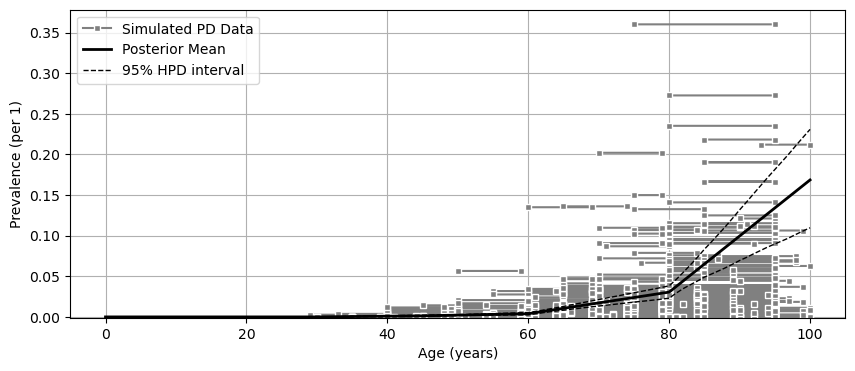

In [10]:
pipeline.visualize_pred(pred, pm_model.shared_data["data"])